# BigCloneBench Type 3 Moderate Graph and Spectral Analysis

Reads graph artifacts produced by `02_extract_graphs.py` and spectral artifacts produced by `03_extract_spectral_features.py` and renders sampled code snippets with their AST/CFG/DDG/PDG/CPG graphs.


In [1]:
from pathlib import Path
import html
import json
import pickle
import random
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import HTML, display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "spectral_code").exists() and (candidate / "pipelines").exists():
            return candidate
    raise RuntimeError("Project root not found.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from spectral_code.utils.dataset_paths import bcb_type_dir, output_root_for

CLONE_TYPE = 3
VARIANT = "3/moderate"
DATA_DIR = bcb_type_dir(VARIANT)
OUTPUT_ROOT = output_root_for("bcb", VARIANT)
GRAPH_MANIFEST_PATH = OUTPUT_ROOT / "clean_graphs" / "graph_shards_manifest.json"
SPECTRAL_MANIFEST_PATH = OUTPUT_ROOT / "spectral_features" / "spectral_features_manifest.json"
PIPELINE_TIMINGS_PATH = OUTPUT_ROOT / "pipeline_timings.json"
GRAPH_TYPES = ["ast", "cfg", "ddg", "pdg", "cpg"]

if not GRAPH_MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Graph manifest not found: {GRAPH_MANIFEST_PATH}. Run ../run_pipeline/02_extract_graphs.py first.")

manifest = json.loads(GRAPH_MANIFEST_PATH.read_text(encoding="utf-8"))
print("Prepared data:", DATA_DIR)
print("Output root:", OUTPUT_ROOT)
print("Graph methods:", manifest.get("total_methods"))
print("Spectral features:", SPECTRAL_MANIFEST_PATH if SPECTRAL_MANIFEST_PATH.exists() else "not found yet")


Prepared data: C:\Users\koush\PyProjects\spectrals\data\bcb\type3\moderate
Output root: C:\Users\koush\PyProjects\spectrals\outputs\bcb\type3\moderate
Graph methods: 7654
Spectral features: C:\Users\koush\PyProjects\spectrals\outputs\bcb\type3\moderate\spectral_features\spectral_features_manifest.json


In [2]:
def load_code_for_ids(path: Path, wanted_ids: set[str]) -> dict[str, str]:
    code_map = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            function_id = str(row["idx"])
            if function_id in wanted_ids:
                code_map[function_id] = row["func"]
                if len(code_map) == len(wanted_ids):
                    break
    return code_map


def sample_pair(path: Path, label: int, seed: int) -> tuple[str, str, int] | None:
    rng = random.Random(seed)
    selected = None
    seen = 0
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            left, right, raw_label = line.rstrip("\n").split("\t")
            raw_label = int(raw_label)
            if raw_label != label:
                continue
            seen += 1
            if rng.randrange(seen) == 0:
                selected = (left, right, raw_label)
    return selected


def sample_method_ids(path: Path, n: int, seed: int) -> list[str]:
    rng = random.Random(seed)
    selected = []
    seen = 0
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            function_id = str(json.loads(line)["idx"])
            seen += 1
            if len(selected) < n:
                selected.append(function_id)
                continue
            slot = rng.randrange(seen)
            if slot < n:
                selected[slot] = function_id
    return selected


def load_graphs_for_ids(manifest: dict, wanted_ids: set[str]) -> dict[str, dict[str, nx.DiGraph]]:
    graphs = {}
    for shard_path in manifest.get("shards", []):
        with Path(shard_path).open("rb") as f:
            shard = pickle.load(f)
        for method_id in list(wanted_ids - set(graphs)):
            if method_id in shard:
                graphs[method_id] = shard[method_id]
        if len(graphs) == len(wanted_ids):
            break
    return graphs


def load_spectral_features_for_ids(manifest_path: Path, wanted_ids: set[str]) -> dict[str, dict]:
    if not manifest_path.exists():
        return {}
    feature_manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    if feature_manifest.get("format") != "spectral_feature_shards_v1":
        raise ValueError(f"Unsupported spectral feature manifest: {manifest_path}")

    features = {}
    for shard_path in feature_manifest.get("shards", []):
        with Path(shard_path).open("rb") as f:
            shard = pickle.load(f)
        for method_id in list(wanted_ids - set(features)):
            if method_id in shard:
                features[method_id] = shard[method_id]
        if len(features) == len(wanted_ids):
            break
    return features


single_method_ids = sample_method_ids(DATA_DIR / "data.jsonl", 2, seed=42)
clone_pair = sample_pair(DATA_DIR / "train.txt", label=1, seed=43)
nonclone_pair = sample_pair(DATA_DIR / "train.txt", label=0, seed=44)
needed_ids = set(single_method_ids)
for pair in [clone_pair, nonclone_pair]:
    if pair:
        needed_ids.update(pair[:2])

code_map = load_code_for_ids(DATA_DIR / "data.jsonl", needed_ids)
graph_map = load_graphs_for_ids(manifest, needed_ids)
spectral_map = load_spectral_features_for_ids(SPECTRAL_MANIFEST_PATH, needed_ids)

print("Single method examples:", single_method_ids)
print("Clone pair:", clone_pair)
print("Non-clone pair:", nonclone_pair)
print("Loaded code snippets:", len(code_map))
print("Loaded graph records:", len(graph_map))
print("Loaded spectral feature records:", len(spectral_map))


Single method examples: ['16930290', '22409057']
Clone pair: ('13617295', '19693671', 1)
Non-clone pair: ('5551857', '17751472', 0)
Loaded code snippets: 6
Loaded graph records: 6
Loaded spectral feature records: 6


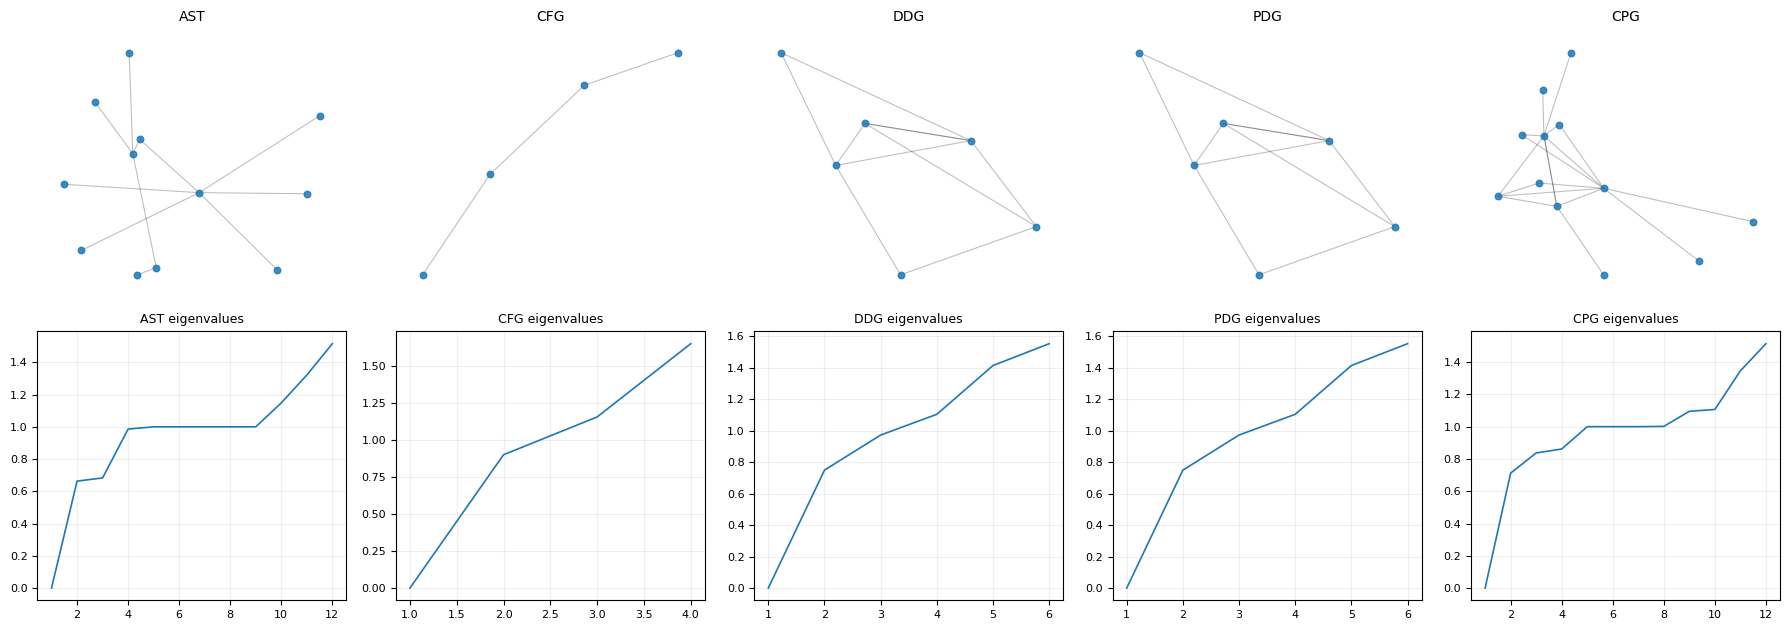

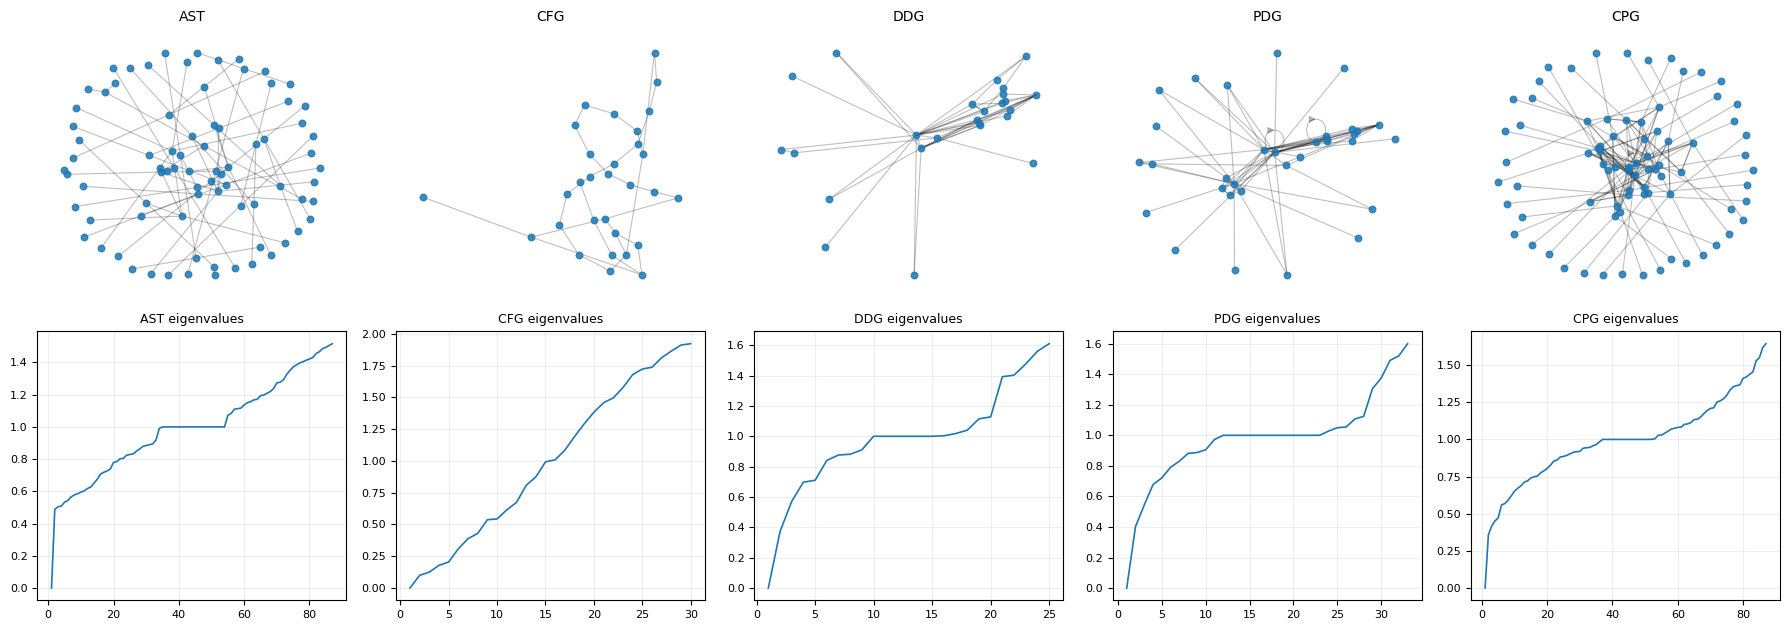

In [3]:
def display_code(method_id: str, title: str) -> None:
    code = html.escape(code_map.get(method_id, ""))
    display(HTML(f"""
    <div style="border:1px solid #d0d7de;border-radius:6px;overflow:hidden;margin:10px 0;">
      <div style="padding:6px 10px;background:#f6f8fa;font-family:system-ui,sans-serif;font-size:13px;">{html.escape(title)} - id {html.escape(method_id)}</div>
      <pre style="margin:0;padding:12px;overflow-x:auto;white-space:pre-wrap;font-size:12px;line-height:1.35;">{code}</pre>
    </div>
    """))


def draw_graph(graph: nx.DiGraph | None, title: str, ax) -> None:
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    if graph is None or graph.number_of_nodes() == 0:
        ax.text(0.5, 0.5, "empty", ha="center", va="center")
        return
    graph = nx.DiGraph(graph)
    if graph.number_of_nodes() > 80:
        nodes = list(graph.nodes())[:80]
        graph = graph.subgraph(nodes).copy()
    pos = nx.spring_layout(graph, seed=42, k=None)
    nx.draw_networkx_edges(graph, pos, ax=ax, arrows=False, alpha=0.25, width=0.8)
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=22, alpha=0.85)


def eigenvalues_for(method_id: str, graph_type: str) -> np.ndarray:
    values = spectral_map.get(method_id, {}).get(graph_type, {}).get("eigenvalues", [])
    values = np.asarray(values, dtype=np.float64)
    return values[np.isfinite(values)]


def draw_eigenvalues(method_id: str, graph_type: str, ax) -> None:
    values = eigenvalues_for(method_id, graph_type)
    ax.set_title(f"{graph_type.upper()} eigenvalues", fontsize=9)
    if values.size == 0:
        ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        return
    ax.plot(np.arange(1, values.size + 1), np.sort(values), linewidth=1.2)
    ax.grid(alpha=0.2)
    ax.tick_params(labelsize=8)


def draw_all_graphs(method_id: str, title: str) -> None:
    display_code(method_id, title)
    fig, axes = plt.subplots(2, len(GRAPH_TYPES), figsize=(18, 6.4))
    for col, graph_type in enumerate(GRAPH_TYPES):
        draw_graph(graph_map.get(method_id, {}).get(graph_type), graph_type.upper(), axes[0][col])
        draw_eigenvalues(method_id, graph_type, axes[1][col])
    plt.tight_layout()
    plt.show()


for idx, method_id in enumerate(single_method_ids, start=1):
    draw_all_graphs(method_id, f"Single code example {idx}")


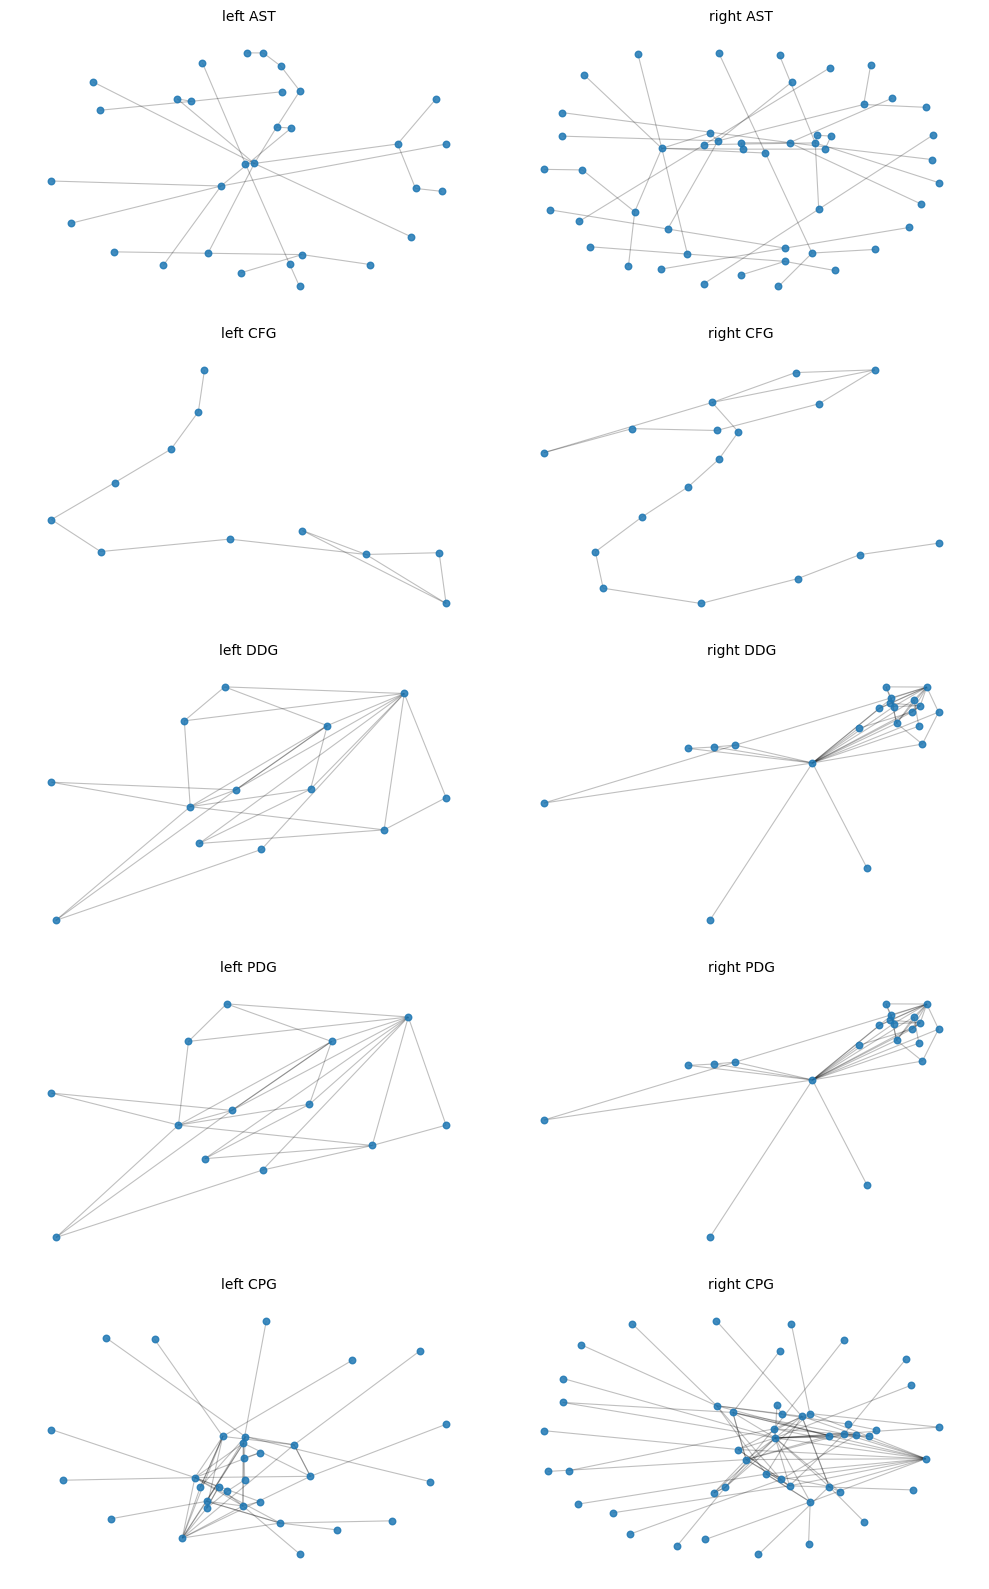

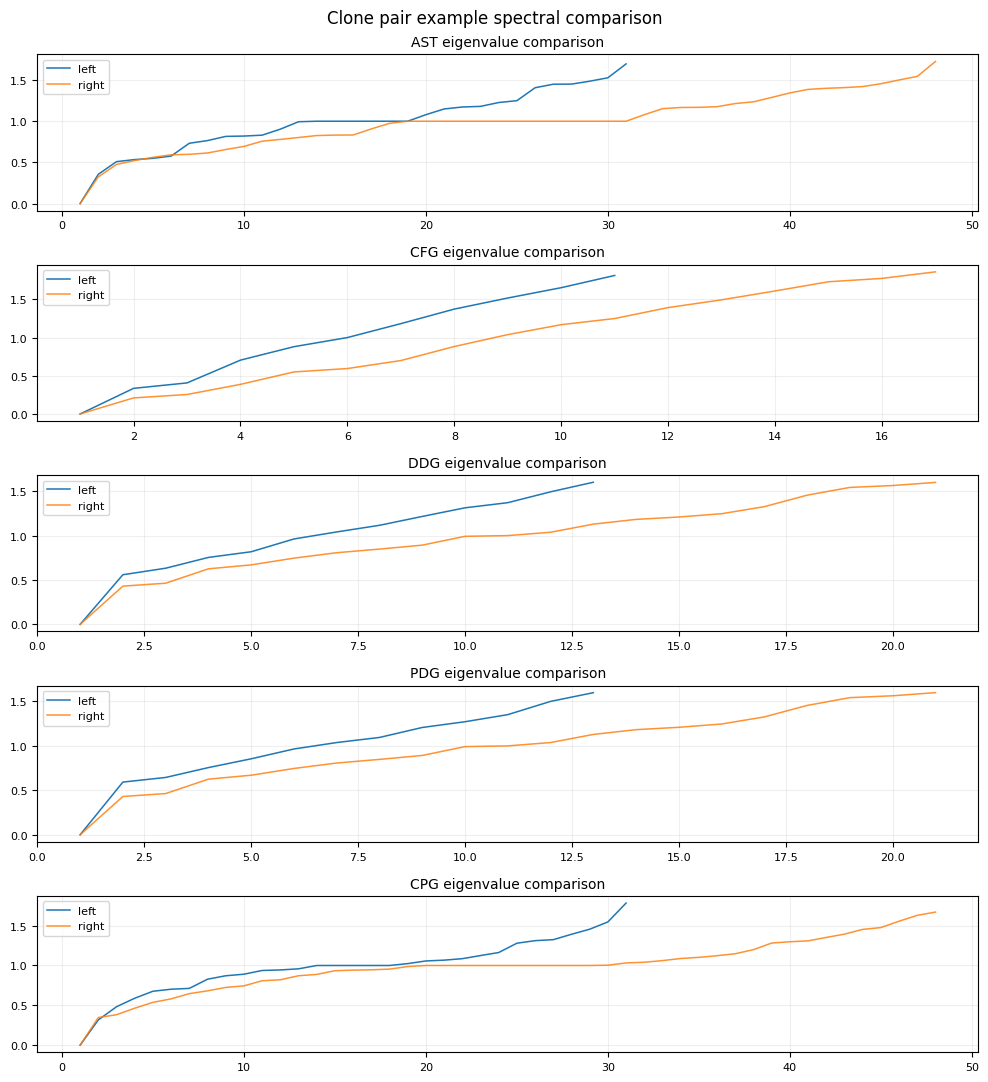

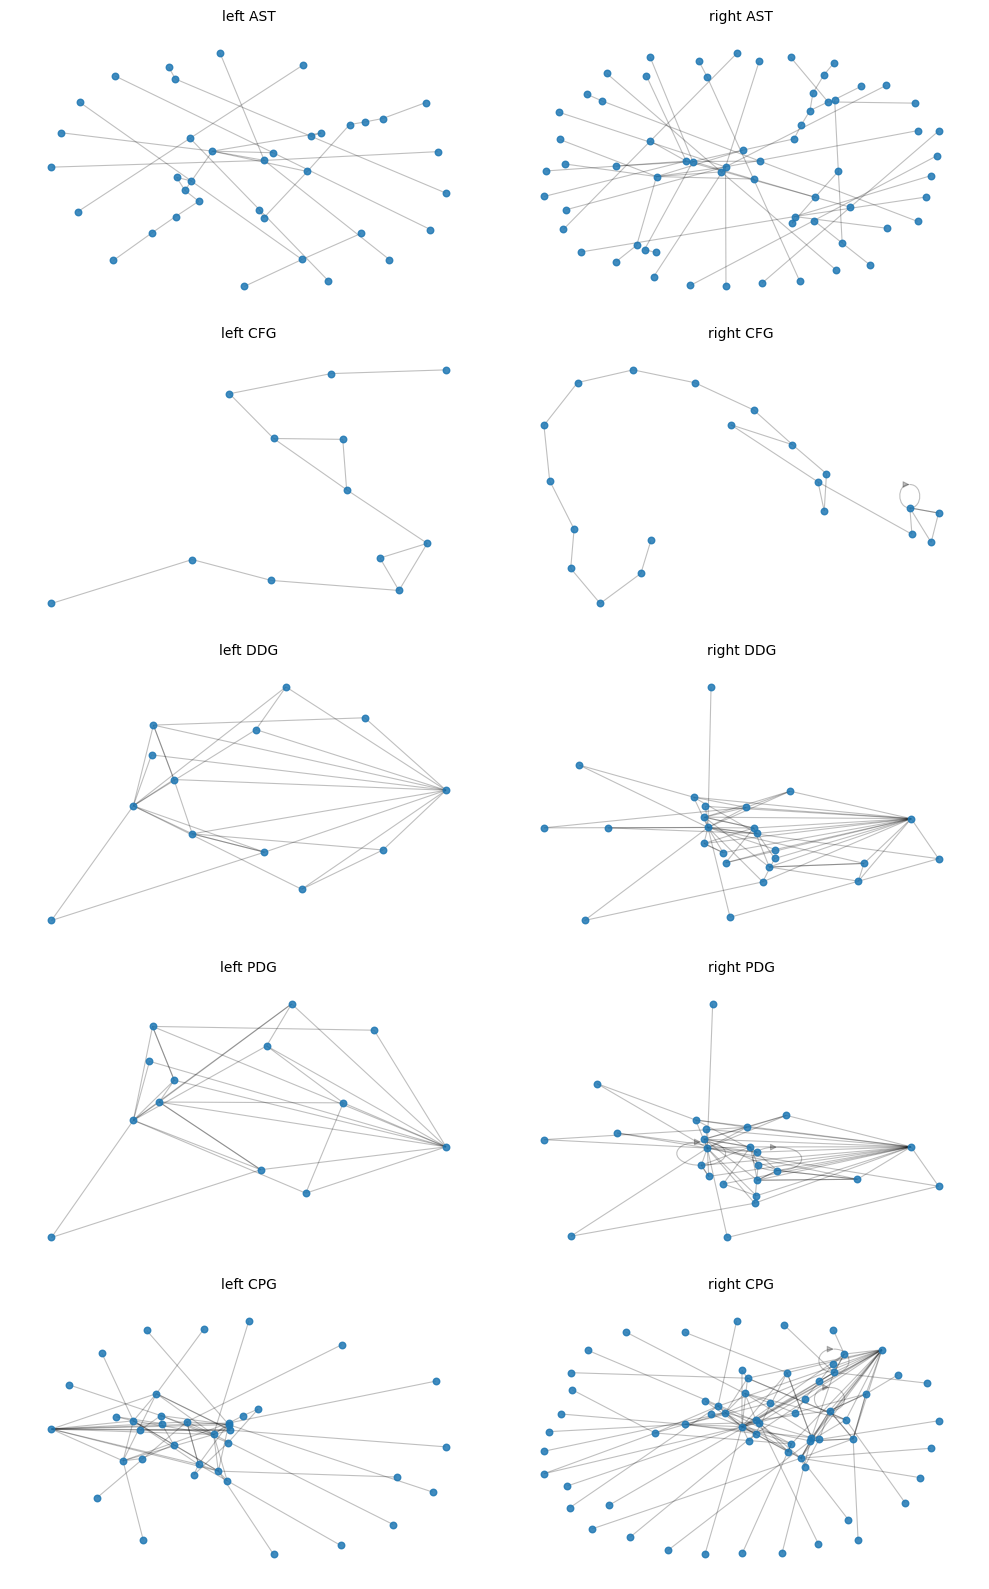

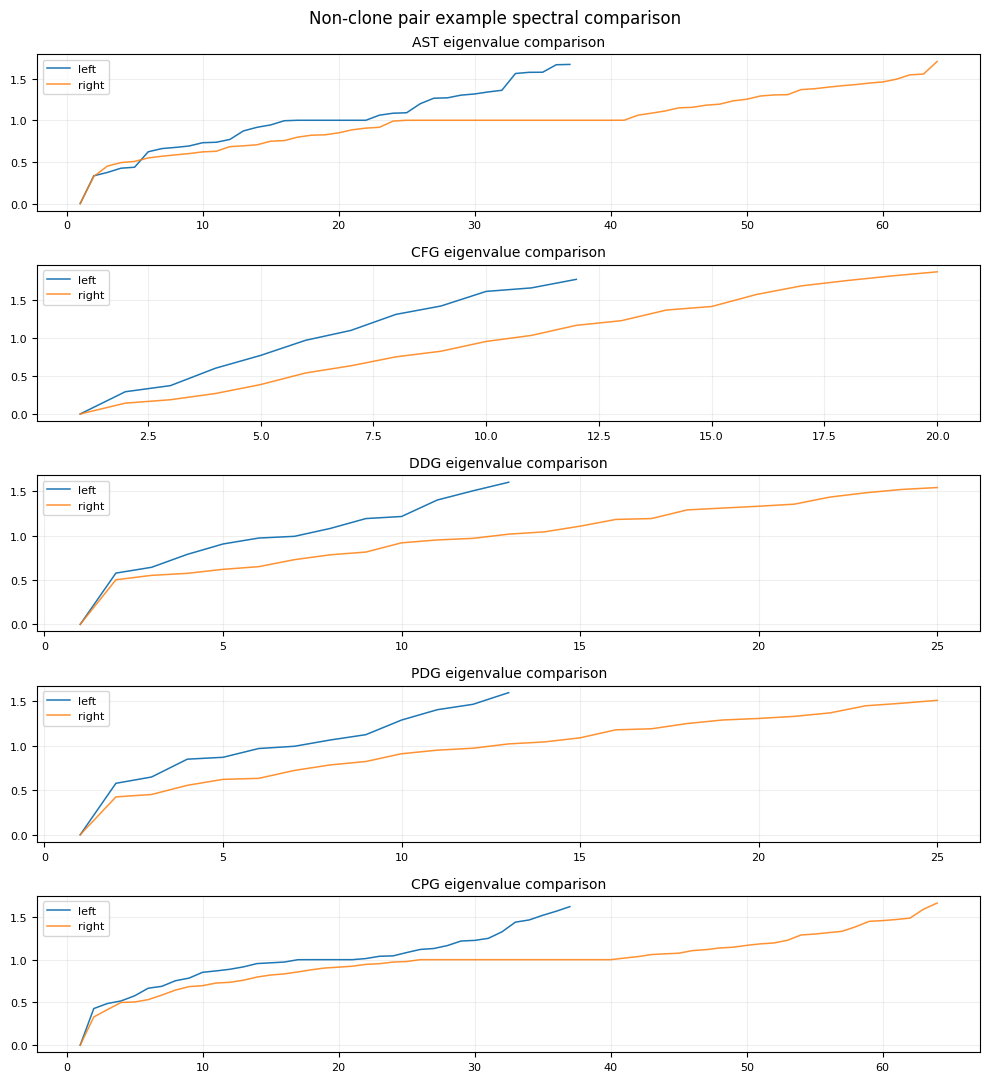

In [4]:
def draw_pair_eigenvalue_comparison(left_id: str, right_id: str, title: str) -> None:
    fig, axes = plt.subplots(len(GRAPH_TYPES), 1, figsize=(10, 11), sharex=False)
    for ax, graph_type in zip(axes, GRAPH_TYPES):
        left_values = eigenvalues_for(left_id, graph_type)
        right_values = eigenvalues_for(right_id, graph_type)
        ax.set_title(f"{graph_type.upper()} eigenvalue comparison", fontsize=10)
        if left_values.size == 0 and right_values.size == 0:
            ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        if left_values.size:
            ax.plot(np.arange(1, left_values.size + 1), np.sort(left_values), label="left", linewidth=1.1)
        if right_values.size:
            ax.plot(np.arange(1, right_values.size + 1), np.sort(right_values), label="right", linewidth=1.1, alpha=0.85)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)
        ax.tick_params(labelsize=8)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


def draw_pair(pair: tuple[str, str, int] | None, title: str) -> None:
    if pair is None:
        display(HTML(f"<b>{html.escape(title)}</b>: no pair with graphs found."))
        return
    left_id, right_id, label = pair
    display(HTML(f"<h3>{html.escape(title)} - label {label}</h3>"))
    display(HTML(f"""
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;align-items:start;">
      <div><b>left id: {html.escape(left_id)}</b><pre style="white-space:pre-wrap;font-size:12px;line-height:1.35;border:1px solid #d0d7de;padding:10px;border-radius:6px;">{html.escape(code_map.get(left_id, ""))}</pre></div>
      <div><b>right id: {html.escape(right_id)}</b><pre style="white-space:pre-wrap;font-size:12px;line-height:1.35;border:1px solid #d0d7de;padding:10px;border-radius:6px;">{html.escape(code_map.get(right_id, ""))}</pre></div>
    </div>
    """))
    fig, axes = plt.subplots(len(GRAPH_TYPES), 2, figsize=(10, 16))
    for row, graph_type in enumerate(GRAPH_TYPES):
        draw_graph(graph_map.get(left_id, {}).get(graph_type), f"left {graph_type.upper()}", axes[row][0])
        draw_graph(graph_map.get(right_id, {}).get(graph_type), f"right {graph_type.upper()}", axes[row][1])
    plt.tight_layout()
    plt.show()
    draw_pair_eigenvalue_comparison(left_id, right_id, f"{title} spectral comparison")


draw_pair(clone_pair, "Clone pair example")
draw_pair(nonclone_pair, "Non-clone pair example")


In [5]:
def stage_runtime_row(stage: str) -> dict:
    timings = json.loads(PIPELINE_TIMINGS_PATH.read_text(encoding="utf-8")) if PIPELINE_TIMINGS_PATH.exists() else {"stages": {}}
    record = timings.get("stages", {}).get(stage, {})
    seconds = record.get("seconds")
    minutes = record.get("minutes")
    if minutes is None and isinstance(seconds, (int, float)):
        minutes = seconds / 60
    return {
        "stage": stage,
        "seconds": round(seconds, 2) if isinstance(seconds, (int, float)) else None,
        "minutes": round(minutes, 2) if isinstance(minutes, (int, float)) else None,
        "updated_at_utc": record.get("updated_at_utc"),
        "status": "recorded" if isinstance(seconds, (int, float)) else "not recorded yet",
        "source": str(PIPELINE_TIMINGS_PATH),
    }


runtime_df = pd.DataFrame([
    stage_runtime_row("02_extract_graphs"),
    stage_runtime_row("03_extract_spectral_features"),
])
display(runtime_df)


,stage,seconds,minutes,updated_at_utc,status,source
0,02_extract_graphs,586.23,9.77,2026-06-27T11:09:09+00:00,recorded,C:\Users\koush\PyProjects\spectrals\outputs\bc...
1,03_extract_spectral_features,201.39,3.36,2026-06-27T11:57:16+00:00,recorded,C:\Users\koush\PyProjects\spectrals\outputs\bc...
